# STAT Forward-Factor — Calibration (the "stat" in FORWARD = stat + climate + grid)

> ## READ THIS FIRST
> Produces the **`stat` forward-factor** artifact the dashboard reads. `stat` is the **FORWARD baseline**
> — the county's own-history forecast of next year's frequency, expressed as a factor on the baseline mean.
> Climate / grid ML are later **challengers that must beat this `stat` baseline** (the ladder).
>
> **Locked design** ([`../../../docs/dicsscssion/forward_regime_statistical_router/04_statistical_adjuster_design.md`](../../../docs/dicsscssion/forward_regime_statistical_router/04_statistical_adjuster_design.md)):
> - method per **regime GROUP**, selected on **coverage-stable years**, with **ASYMMETRIC loss**
>   (under-prediction penalised 3× — under-reserving is the dangerous error → [`model_to_the_consequence`]);
> - **ONE-DIRECTIONAL**: `factor = max(1.0, forecast/λ_full)` — uplift or **abstain**, **never discount** in v1
>   (a declining county keeps the higher full-mean = cushion);
> - **CREDIBILITY-shrunk** toward ×1.0 on thin data, **capped**, **SHADOW** (not in the quoted premium).
>
> **Honest framing:** because `λ_full` is biased low by EAGLE-I coverage ramp, `stat` mostly **UPLIFTS** —
> it is largely a *per-county recent-vs-historical level correction* (~+16–20% typical), not a subtle nudge.
> The baseline stays the raw audit anchor. Calibration lives HERE; the dashboard does arithmetic on the artifact.

## §00 — Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
ROOT=Path.cwd()
while not (ROOT/"curated_outage_data").exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
CATALOG="eagle-i-45min"; STABLE_FROM=2018; W_UNDER,W_OVER=3.0,1.0; CAP_HI=1.5; CRED_FULL=300.0; CONF_LOW=0.6
TREND=ROOT/f"curated_outage_data/outputs/county_trend/county_yearly_trend__{CATALOG}.parquet"
REGIME=ROOT/"notebooks/outputs/regime_classification/county_regime_T8.csv"
OUT=ROOT/"notebooks/outputs/forward_regime/statistical_router"; OUT.mkdir(parents=True,exist_ok=True)
print("ROOT",ROOT,"| asym",f"{W_UNDER:.0f}:{W_OVER:.0f}","| cap",CAP_HI,"| cred_full",CRED_FULL)

ROOT /Users/divy/code/work/infrasure_git_codes/outage_pricing | asym 3:1 | cap 1.5 | cred_full 300.0


## §01 — Load counts + regime grouping

In [2]:
tr=pd.read_parquet(TREND); tr["fips"]=tr["fips"].astype(str).str.zfill(5)
reg=pd.read_csv(REGIME,dtype={"fips":str}); reg["fips"]=reg["fips"].str.zfill(5)
rm=reg.set_index("fips")["regime"].to_dict(); cm=reg.set_index("fips")["conf"].to_dict()
def ob(r):
    y=np.asarray(r["years"],int); c=np.asarray(r["yearly_counts"],float); m=np.asarray(r["observed_year_mask"],bool); return y[m],c[m]
RO=["stable","trend","shift","episodic","insufficient"]
print("regime groups:",reg.regime.value_counts().reindex(RO).to_dict())

regime groups: {'stable': 1306, 'trend': 718, 'shift': 675, 'episodic': 47, 'insufficient': 344}


## §02 — Experts + per-regime method selection (coverage-stable, ASYMMETRIC loss)

In [3]:
def flat(yr,y,ny): return float(np.mean(y))
def rec3(yr,y,ny): return float(np.mean(y[-3:]))
def rec5(yr,y,ny): return float(np.mean(y[-5:]))
def wrec(yr,y,ny,a=0.6):
    w=a**(np.arange(len(y))[::-1]); return float(np.sum(w*y)/np.sum(w))
def lin(yr,y,ny):
    b,a=np.polyfit(yr,y,1); return float(max(0,a+b*ny))
def capl(yr,y,ny):
    m=np.mean(y); return float(np.clip(lin(yr,y,ny),0.5*m,2*m))
def persist(yr,y,ny): return float(y[-1])
EX={"flat":flat,"recent_k3":rec3,"recent_k5":rec5,"wtd_recent":wrec,"capped_lin":capl,"persist":persist}; EN=list(EX)
def asym(p,o): return W_UNDER*max(0,o-p)+W_OVER*max(0,p-o)
rows=[]
for _,r in tr.iterrows():
    fips,T=r["fips"],int(r["T"]); rg=rm.get(fips)
    if rg is None: continue
    y,c=ob(r); ys=y[y>=STABLE_FROM]; cs=c[y>=STABLE_FROM]
    al={e:0.0 for e in EN}; sob=0.0; nf=0
    for ty in range(2022,2026):
        if ty not in ys: continue
        m=ys<ty
        if m.sum()<3: continue
        o=float(cs[ys==ty][0]); sob+=o; nf+=1
        for e in EN: al[e]+=asym(EX[e](ys[m],cs[m],float(ty)),o)
    if nf>=2 and sob>=5:
        for e in EN: rows.append((rg,e,al[e]/sob))
S=pd.DataFrame(rows,columns=["regime","expert","al"]); piv=S.groupby(["regime","expert"]).al.median().unstack().reindex(RO)[EN]
best_re={rg:piv.loc[rg].idxmin() for rg in RO}
print("per-regime method (asymmetric loss penalises under-prediction => leans to the UPWARD method):")
for rg in RO: print(f"  {rg:<13} -> {best_re[rg]}")
print("\nNOTE: the asymmetric weight is a MINOR knob — symmetric gives a similar magnitude; the large")
print("uplift below is STRUCTURAL (forecast vs the coverage-biased-low full mean), not a tuning artifact.")

per-regime method (asymmetric loss penalises under-prediction => leans to the UPWARD method):
  stable        -> wtd_recent
  trend         -> capped_lin
  shift         -> capped_lin
  episodic      -> persist
  insufficient  -> persist

NOTE: the asymmetric weight is a MINOR knob — symmetric gives a similar magnitude; the large
uplift below is STRUCTURAL (forecast vs the coverage-biased-low full mean), not a tuning artifact.


## §03 — The calibrated `stat` factor
`stat_factor = clip( 1 + (max(1.0, forecast/λ_full) − 1) × credibility , 1.0 , 1.5 )`, abstain on `insufficient`.
Credibility `Z = clip(√(total_events/300),0,1) × (1.0 high-conf | 0.6 low-conf)`, `0` for insufficient.

In [4]:
def cred(tot,conf,rg):
    if rg=="insufficient": return 0.0
    return float(np.clip(np.sqrt(tot/CRED_FULL),0,1))*(1.0 if conf=="high" else CONF_LOW)
recs=[]
for _,r in tr.iterrows():
    fips,T=r["fips"],int(r["T"]); rg=rm.get(fips)
    if rg is None: continue
    y,c=ob(r)
    if len(c)<3 or c.mean()<=0: continue
    lf=float(c.mean()); fc=EX[best_re[rg]](y,c,2026.0); raw=fc/lf; up=max(1.0,raw)
    Z=cred(float(c.sum()),cm.get(fips),rg); f=float(np.clip(1+(up-1)*Z,1.0,CAP_HI))
    recs.append((fips,T,rg,best_re[rg],cm.get(fips,""),round(lf,4),round(fc,4),round(raw,4),round(Z,4),round(f,4)))
F=pd.DataFrame(recs,columns=["fips","T","regime","expert","conf","lam_full","forecast","raw_factor","credibility","stat_factor"])
print(f"calibrated cells: {len(F):,}")

calibrated cells: 15,063


## §04 — Characterise the factor (and confirm the safeguards fire)

STAT factor at T=8h (one-directional · credibility-shrunk · capped 1.5 · SHADOW):
  median 1.149  mean 1.204  p90 1.500  at cap 18%
  UPLIFT >1.02: 70%   HOLD ~1.0: 30%
  by regime (median | %uplift | %hold | median credibility):
    stable        1.06 | up  63% | hold  37% | cred 0.60
    trend         1.46 | up  95% | hold   5% | cred 0.65
    shift         1.35 | up  90% | hold  10% | cred 0.65
    episodic      1.00 | up  11% | hold  89% | cred 0.28
    insufficient  1.00 | up   0% | hold 100% | cred 0.00

SAFEGUARDS:
  insufficient abstains (==1.0): 100%
  declining counties never discount (min factor): 1.00  (floor 1.0 holds)


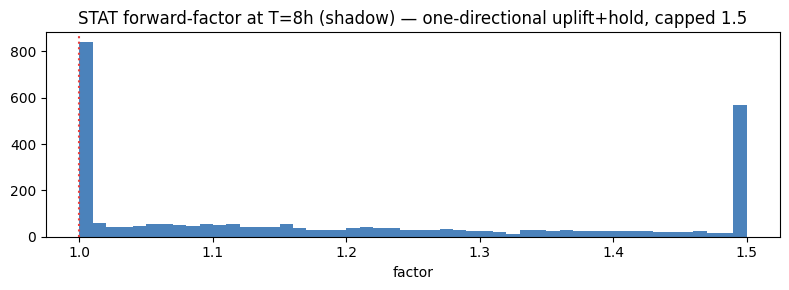

In [5]:
f8=F[F["T"]==8]
print("STAT factor at T=8h (one-directional · credibility-shrunk · capped 1.5 · SHADOW):")
print(f"  median {f8.stat_factor.median():.3f}  mean {f8.stat_factor.mean():.3f}  p90 {f8.stat_factor.quantile(.9):.3f}  at cap {(f8.stat_factor>=1.499).mean()*100:.0f}%")
print(f"  UPLIFT >1.02: {(f8.stat_factor>1.02).mean()*100:.0f}%   HOLD ~1.0: {(f8.stat_factor<=1.02).mean()*100:.0f}%")
print("  by regime (median | %uplift | %hold | median credibility):")
for rg in RO:
    s=f8[f8.regime==rg]
    if len(s): print(f"    {rg:<13} {s.stat_factor.median():.2f} | up {(s.stat_factor>1.02).mean()*100:3.0f}% | hold {(s.stat_factor<=1.02).mean()*100:3.0f}% | cred {s.credibility.median():.2f}")
print("\nSAFEGUARDS:")
print(f"  insufficient abstains (==1.0): {(f8[f8.regime=='insufficient'].stat_factor==1.0).mean()*100:.0f}%")
print(f"  declining counties never discount (min factor): {f8.stat_factor.min():.2f}  (floor 1.0 holds)")
fig,ax=plt.subplots(figsize=(8,3)); ax.hist(f8.stat_factor,bins=50,color="#2b6cb0",alpha=.85); ax.axvline(1.0,color="#e53e3e",ls=":")
ax.set_title("STAT forward-factor at T=8h (shadow) — one-directional uplift+hold, capped 1.5"); ax.set_xlabel("factor"); plt.tight_layout(); plt.show()

## §05 — What it means: annual series, forecast vs full-mean (per-county)

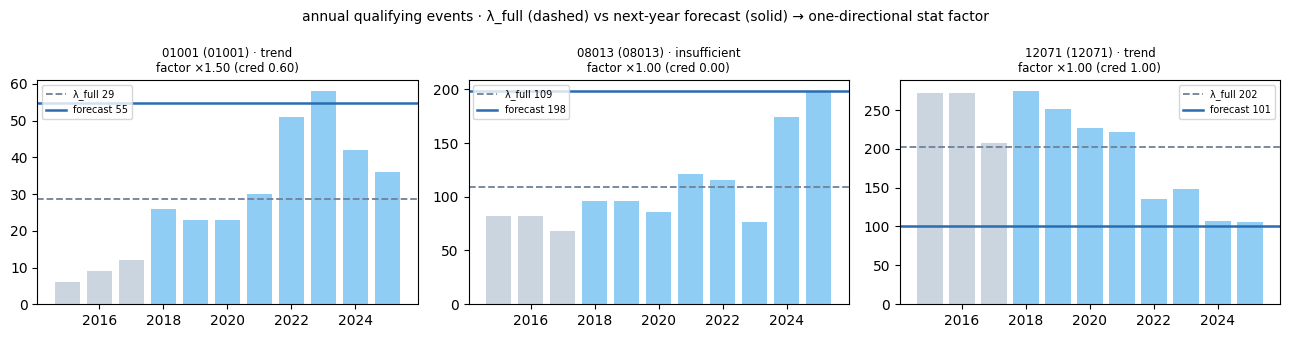

In [6]:
name={}
try:
    import json; cbs=json.load(open(ROOT/"web/lib/data/counties-by-state.json"))
    def walk(o):
        if isinstance(o,dict):
            if "fips" in o and ("name" in o or "county" in o): name[str(o["fips"]).zfill(5)]=o.get("name") or o.get("county")
            for v in o.values(): walk(v)
        elif isinstance(o,list):
            for v in o: walk(v)
    walk(cbs)
except Exception: pass
def lbl(f): return f"{name.get(f,f)} ({f})"
ex=["01001",                                                        # coverage-suppressed -> uplift
    f8.loc[(f8.lam_full>=20)&(f8.regime=='insufficient')].fips.iloc[0] if len(f8[(f8.regime=='insufficient')&(f8.lam_full>=20)]) else "37183",  # abstain
    "12071"]                                                        # declining -> holds (one-directional)
fig,axes=plt.subplots(1,3,figsize=(13,3.4))
for ax,f in zip(axes,ex):
    r=tr[(tr.fips==f)&(tr["T"]==8)].iloc[0]; y,c=ob(r); x=F[(F.fips==f)&(F["T"]==8)].iloc[0]
    ax.bar(y,c,color=["#cbd5e0" if yy<STABLE_FROM else "#90cdf4" for yy in y])
    ax.axhline(x.lam_full,color="#718096",ls="--",lw=1.3,label=f"λ_full {x.lam_full:.0f}")
    ax.axhline(x.forecast,color="#2b6cb0",ls="-",lw=1.8,label=f"forecast {x.forecast:.0f}")
    ax.set_title(f"{lbl(f)} · {x.regime}\nfactor ×{x.stat_factor:.2f} (cred {x.credibility:.2f})",fontsize=8.5); ax.legend(fontsize=7)
fig.suptitle("annual qualifying events · λ_full (dashed) vs next-year forecast (solid) → one-directional stat factor",fontsize=10)
plt.tight_layout(); plt.show()

## §06 — Where the uplift concentrates (national map, T=8h)

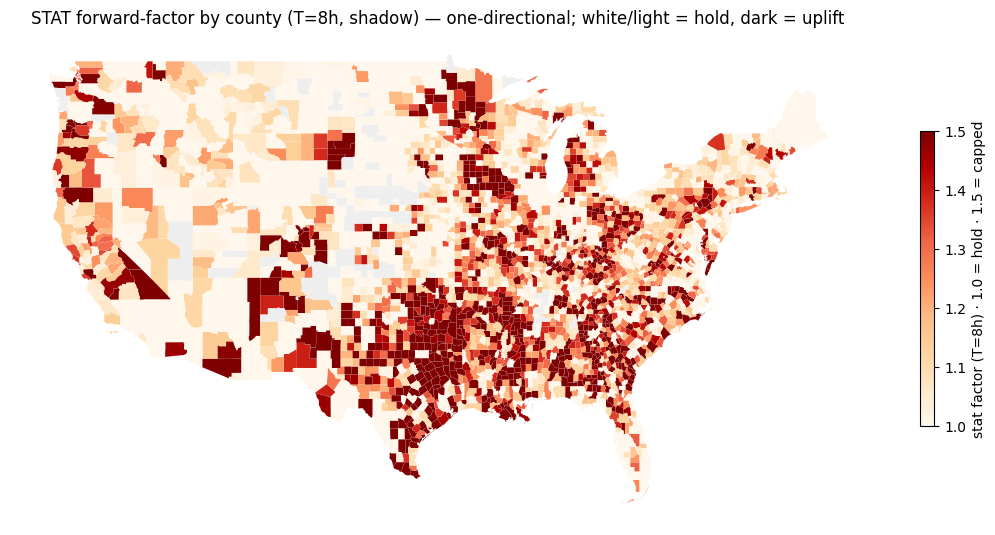

In [7]:
import geopandas as gpd
from matplotlib.colors import TwoSlopeNorm
GJ=OUT/"geojson-counties-fips.json"
if not GJ.exists():
    import urllib.request; urllib.request.urlretrieve("https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",GJ)
g=gpd.read_file(GJ); g["fips"]=g["id"].astype(str).str.zfill(5)
g=g[~g["fips"].str[:2].isin(["02","15"])]; g=g[g["fips"].str[:2].astype(int)<60]
m=g.merge(f8[["fips","stat_factor"]],on="fips",how="left")
fig,ax=plt.subplots(figsize=(11,6.2))
m.plot(column="stat_factor",cmap="OrRd",vmin=1.0,vmax=1.5,linewidth=0.05,edgecolor="#fff",ax=ax,legend=True,
       missing_kwds={"color":"#eee"},legend_kwds={"label":"stat factor (T=8h) · 1.0 = hold · 1.5 = capped","shrink":0.5})
ax.set_title("STAT forward-factor by county (T=8h, shadow) — one-directional; white/light = hold, dark = uplift"); ax.axis("off"); plt.tight_layout(); plt.show()

## §07 — Validation (conservative by construction)

In [8]:
# the factor only ever raises or holds -> the forward view can only ADD cushion vs the baseline mean
print(f"factor range: [{f8.stat_factor.min():.2f}, {f8.stat_factor.max():.2f}]  (floored at 1.0 => never reduces premium)")
print(f"share that HOLD (no change from baseline): {(f8.stat_factor<=1.02).mean()*100:.0f}%")
print(f"share UPLIFTED: {(f8.stat_factor>1.02).mean()*100:.0f}%  (correcting the coverage-biased-low baseline, per-county)")
print(f"thin/low-confidence shrink works: median credibility by conf -> high {f8[f8.fips.map(cm)=='high'].credibility.median():.2f}, low {f8[f8.fips.map(cm)=='low'].credibility.median():.2f}")

factor range: [1.00, 1.50]  (floored at 1.0 => never reduces premium)
share that HOLD (no change from baseline): 30%
share UPLIFTED: 70%  (correcting the coverage-biased-low baseline, per-county)
thin/low-confidence shrink works: median credibility by conf -> high 1.00, low 0.49


## §08 — Emit the `stat` forward-factor artifact (shadow; dashboard reads this)

In [9]:
art=F[["fips","T","regime","expert","conf","lam_full","forecast","raw_factor","credibility","stat_factor"]]
art.to_parquet(OUT/"stat_forward_factor.parquet"); art.to_csv(OUT/"stat_forward_factor.csv",index=False)
# compact JSON the dashboard reads (math-only on the platform; calibration lives here)
import json as _json
fj={}
for fips,g in F.groupby("fips"):
    g0=g.iloc[0]
    fj[fips]={"regime":g0.regime,"expert":g0.expert,"conf":g0.conf,
              "T":{str(int(r.T)):{"f":round(r.stat_factor,4),"lam_full":round(r.lam_full,4),"fc":round(r.forecast,4),"cred":round(r.credibility,4),"raw":round(r.raw_factor,4)} for r in g.itertuples()}}
_json.dump(fj,open(OUT/"forward_factor.json","w"),separators=(",",":"))
print("forward_factor.json counties:",len(fj))
card=f'''# STAT forward-factor — model card ({CATALOG})
- stat_factor = clip(1 + (max(1, forecast/λ_full) − 1) × credibility, 1.0, {CAP_HI}); abstain on `insufficient`.
- method per regime (asym {W_UNDER:.0f}:{W_OVER:.0f}, coverage-stable): {best_re}
- T=8h: median {f8.stat_factor.median():.2f} · mean {f8.stat_factor.mean():.2f} · {(f8.stat_factor>1.02).mean()*100:.0f}% uplift · {(f8.stat_factor>=1.499).mean()*100:.0f}% at cap.
- ONE-DIRECTIONAL (never discounts) · credibility-shrunk · capped · SHADOW (not in quoted premium).
- honest: largely a per-county coverage/level correction (λ_full biased low); asym weight is a minor knob (magnitude is structural).
- status: the FORWARD baseline (stat in stat+climate+grid). Climate/grid ML must beat it. Validate before any live move.'''
(OUT/"stat_forward_factor_model_card.md").write_text(card)
(OUT/"stat_assumptions_to_register.md").write_text("A018 (proposed) — FORWARD stat factor: per-regime forecast vs full-period mean; asymmetric loss; one-directional (uplift+abstain); credibility-shrunk; capped; shadow. The forward baseline ML challengers must beat.")
print("wrote:", *[p.name for p in sorted(OUT.glob('stat_*'))])

forward_factor.json counties: 3028
wrote: stat_assumptions_to_register.md stat_forward_factor.csv stat_forward_factor.parquet stat_forward_factor_model_card.md


## §09 — Verdict

In [10]:
print(f'''VERDICT — the STAT forward baseline is calibrated (SHADOW)
- It is the 'stat' in FORWARD = stat + climate + grid; the baseline climate/grid ML must beat.
- T=8h: median ×{f8.stat_factor.median():.2f}, mean ×{f8.stat_factor.mean():.2f}; {(f8.stat_factor>1.02).mean()*100:.0f}% uplift, {(f8.stat_factor<=1.02).mean()*100:.0f}% hold.
- HONEST: it is largely a PER-COUNTY coverage/level correction (the full mean is biased low) — a sizeable,
  one-directional UPWARD move, not a subtle nudge. The asymmetric loss is a minor conservative lean.
- Safeguards fire: insufficient abstains; declining counties hold at 1.0 (never discount = cushion);
  thin/low-confidence counties shrink toward 1.0; capped at +50%.
- Conservative by construction: can only ADD cushion vs the baseline mean.
- Status: SHADOW. Next: wire the dashboard FORWARD bracket -> 'stat + climate + grid' + drop-down. No live move.''')

VERDICT — the STAT forward baseline is calibrated (SHADOW)
- It is the 'stat' in FORWARD = stat + climate + grid; the baseline climate/grid ML must beat.
- T=8h: median ×1.15, mean ×1.20; 70% uplift, 30% hold.
- HONEST: it is largely a PER-COUNTY coverage/level correction (the full mean is biased low) — a sizeable,
  one-directional UPWARD move, not a subtle nudge. The asymmetric loss is a minor conservative lean.
- Safeguards fire: insufficient abstains; declining counties hold at 1.0 (never discount = cushion);
  thin/low-confidence counties shrink toward 1.0; capped at +50%.
- Conservative by construction: can only ADD cushion vs the baseline mean.
- Status: SHADOW. Next: wire the dashboard FORWARD bracket -> 'stat + climate + grid' + drop-down. No live move.
